In [6]:
from toolbox import tissueSample
iter = 0
driven = [166,251,291,156,186]
dir = "7_7/"
file = "{}.bulk.txt".format(iter)
sample = tissueSample.Sample.periodic_tissue(config_dir= dir, input_filename= file)
sample.load_periodic_tissue_cell_properties()
for cellID in driven:
    sc = sample.extract_cell(cellID)
    sc.dump_vtk("cell_{}.vtk".format(cellID))

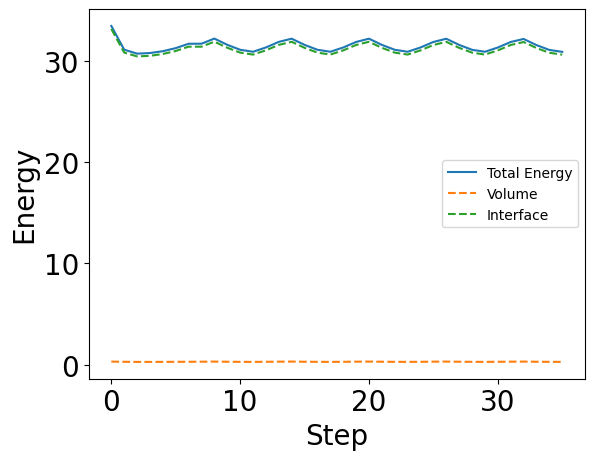

In [2]:
energy = []
volume = []
interface = []
with open("10_0/FE.txt","r") as f:
    lines = f.readlines()
    for line in lines:
        if not len(line.split()):
            continue
        if line.split()[0] =="Energy":
            energy.append(float(line.split()[1]))
        if line.split()[0] =="Volume":
            volume.append(float(line.split()[1]))
        if line.split()[0] =="Interface":
            interface.append(float(line.split()[1]))
import matplotlib.pyplot as plt

time = [i for i in range(len(energy))]
plt.plot(time, energy, label = "Total Energy")
plt.plot(time, volume, linestyle= "--",label = "Volume")
plt.plot(time, interface, linestyle= "--", label = "Interface")
plt.xlabel("Step",fontsize = 20)
plt.ylabel("Energy",fontsize = 20)
plt.tick_params(labelsize = 20)
plt.legend()

In [ ]:
from toolbox import tissueSample
i = 0
sample = tissueSample.Sample.periodic_tissue("7_1/","{}.bulk.txt".format(i))
sample.load_periodic_tissue_cell_properties()


In [6]:
from toolbox import tissueSample
dir = "7_5/"
for iter in range(3):
    filename = "{}.bulk.txt".format(iter)
    sample = tissueSample.Sample.periodic_tissue(config_dir=dir,input_filename=filename)
    sample.load_periodic_tissue_cell_properties()
    for cellID,cell in sample.cells_.items():
        if cell.crossBoundary_:
            continue
        print(cellID, cell.volume_, cell.shape_index_)



0 1.0020044932376266 5.362028214537873
3 0.9991169354765908 5.378322022641627
5 1.0048897918721182 5.346862368531118
6 0.9966399789095549 5.410430260896438
7 0.9978404689269096 5.386913750683922
10 0.9971662383439448 5.389674574359843
13 0.9992063400809121 5.381760694234896
15 1.0017352325348965 5.363975074930943
16 1.0101874129787478 5.316901135697327
18 0.9999372703563735 5.379392563517945
19 0.9951816963113759 5.404822295416547
20 1.0003422226826353 5.379436711639534
23 0.9997697470790411 5.3796592270344465
24 1.0121018889081201 5.3143231885265045
25 0.9653208037937144 5.548415049733337
28 1.0096391478897626 5.330123141830401
32 0.9763793330927746 5.501716368265701
34 1.0102197762434795 5.321301357384383
36 0.9933317666916295 5.403804998288229
37 0.9912736359952041 5.431531527369834
38 0.9886491769583803 5.445718790518945
39 0.996808392901086 5.403074503206874
40 1.0064178280444533 5.359428686296685
43 0.8864125514481376 5.589195116791951
46 0.9992702072513777 5.375650908536436
48 1

In [ ]:
from toolbox.training import pulseDrive

tr = pulseDrive.from_config("7_2/","sample.topo")
for _ in range(10):
    tr.pick_modified_cell()

# tr.run(iterations = 10)

[2.19006556 2.26139778 4.01812833]
[4.93227731 2.15919462 2.08787577]
[2.61239389 3.86310556 2.40525111]
[4.47851937 3.85340781 4.35561531]
[2.12400531 2.82006125 2.30068813]
[3.958909   2.20917967 3.214702  ]
[4.68552409 3.963835   3.32275273]
[2.80716438 4.8345725  4.07457875]
[3.57792462 4.51697462 2.59207769]
[2.85404    2.31753833 2.76920792]


0 0.998435955295277 5.379476782141717
3 1.0000415250449484 5.372471053122064
6 0.9880751937165165 5.408659636730813
7 0.9835768894262014 5.414972436565459
15 1.0126050727930265 5.367298593146772
16 0.9878970374493234 5.400688664167528
18 1.0051058046216932 5.368529267209648
19 0.988383512450398 5.402024657448635
20 1.0104087422122372 5.365336039164625
23 0.9868395613849884 5.408444283584613
24 1.0140984408665241 5.3522657843496
25 0.9814301265400078 5.398992039600662
28 1.009823415687599 5.377549576649232
32 0.9976583489582808 5.37659586061492
34 1.0045708415719417 5.367313306865964
36 0.9982863430207365 5.379500859463387
37 1.0637701210235002 5.600576890342775
38 1.0071932647574355 5.365418884132952
39 1.0081717380389204 5.373713174857923
40 1.0107215161204228 5.374007180267894
46 0.9948388192133537 5.392908126422675
48 1.008847367079678 5.356797215558684
50 0.9967383794687376 5.379200708430596
56 0.997900160773703 5.403965236280593
57 0.9897376158258729 5.405327220740293
60 1.0056089

(array([40., 97., 30.,  3.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([5.34463846, 5.3702323 , 5.39582614, 5.42141999, 5.44701383,
        5.47260767, 5.49820152, 5.52379536, 5.5493892 , 5.57498305,
        5.60057689]),
 <BarContainer object of 10 artists>)

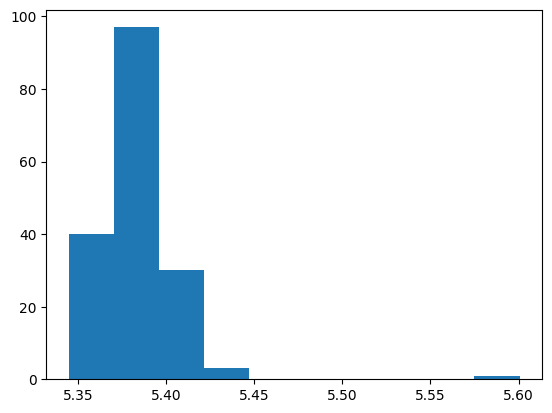

In [2]:
tr._config.load_periodic_tissue_cell_properties()
volumes = []
areas = []
for cellID,cell in tr._config.cells_.items():
    if cell.crossBoundary_:
        continue
    volumes.append(cell.volume_)
    areas.append(cell.surface_area_)
    print(cellID,cell.volume_,cell.surface_area_)
import matplotlib.pyplot as plt

# plt.hist(volumes)

plt.hist(areas)

In [1]:
from toolbox import tissueSample
dir = "final/"
samples = {i:tissueSample.Sample.periodic_tissue(config_dir=dir,input_filename="{:07d}.sample.topo".format(i)) for i in range(21)}
for i, sample in samples.items():
    sample.sample_center_ = sample.cells_[211].center_
    sample.time_ = i
    sample.load_periodic_tissue_cell_properties()
    cell = sample.extract_cell(211)
    cell.dump_vtk(dir+"{:07d}.fixed.vtk".format(i))

In [5]:
def load_shape_index_change(sample0:tissueSample.Sample,sample1:tissueSample.Sample):
    cellIDs = []
    for cellID,cell in sample0.cells_.items():
        if cell.crossBoundary_:
            continue
        if cellID not in sample1.cells_:
            continue
        if sample1.cells_[cellID].crossBoundary_:
            continue
        cellIDs.append(cellID)
    diff_shape_indices = {cellID:sample1.cells_[cellID].shape_index_-sample0.cells_[cellID].shape_index_ for cellID in cellIDs}
    for cellID,change in diff_shape_indices.items():
        sample1.cells_[cellID].shape_index_change_ = change

for i in range(1,21):
    load_shape_index_change(samples[i-1],samples[i])

In [3]:
from toolbox import functions
# def create_change_vtk(sample0:tissueSample.Sample,sample1:tissueSample.Sample,filename:str):
def create_change_vtk(sample:tissueSample.Sample,filename:str):

    vertices = []
    total_polygons = 0
    total_polygon_data_points = 0
    for polygonID,polygon in sample.polygons_.items():
        if polygon.crossBoundary_:
            continue
        total_polygons += 1
        total_polygon_data_points += len(polygon.vertices_) + 1
        for vertex in polygon.vertices_:
            vertices.append(vertex)
    vertices = list(set(vertices))
    v_map = functions.mapmaker(vertices)
    with open("{}".format(filename),"w") as f:
        f.write("# vtk DataFile Version 2.0\n")
        f.write("polydata\n")
        f.write("ASCII\n")
        f.write("DATASET POLYDATA\n")
        f.write("POINTS {} double\n".format(len(vertices)))
        for vertexID in vertices:
            for i in range(3):
                f.write("{} ".format(sample.vertices_[vertexID].position_[i]))
            f.write("\n")
        f.write("POLYGONS {} {}\n".format(total_polygons,total_polygon_data_points))
        for polygonID,polygon in sample.polygons_.items():
            if polygon.crossBoundary_:
                continue
            f.write("{} ".format(len(polygon.vertices_)))
            for vertexID in polygon.vertices_:
                f.write("{} ".format(v_map[vertexID]))
            f.write("\n")
        f.write("CELL_DATA {}\n".format(total_polygons))
        # f.write("SCALARS is_fixed double\n")
        # f.write("LOOKUP_TABLE default\n")
        # for polygonID,polygon in sample.polygons_.items():
        #     if polygon.crossBoundary_:
        #         continue
        #     if polygon.is_fixed_:
        #         f.write("1\n")
        #     else:
        #         f.write("0\n")
        # f.write("SCALARS vol_changes double\n")
        # f.write("LOOKUP_TABLE default\n")
        # for polygonID,polygon in sample.polygons_.items():
        #     if polygon.crossBoundary_:
        #         continue
        #     for cellID,cell in sample.cells_.items():
        #         if polygonID in cell.polygons_:
        #             if diff_volumes[cellID] is None:
        #                 f.write("0\n")
        #                 break
        #             else:
        #                 f.write("{:.14f}\n".format(diff_volumes[cellID]))
        #                 break
        f.write("SCALARS shape_index_changes double\n")
        f.write("LOOKUP_TABLE default\n")
        for polygonID,polygon in sample.polygons_.items():
            if polygon.crossBoundary_:
                continue
            for cellID,cell in sample.cells_.items():
                if polygonID in cell.polygons_:
                    if cell.shape_index_change_ is None:
                        f.write("0\n")
                        break
                    else:
                        f.write("{:.14f}\n".format(cell.shape_index_change_))
                        break

for i in range(1,21):
    create_change_vtk(samples[i],dir+"{:07d}.change.vtk".format(i))

[4.7764143  5.50237281 4.57071798]


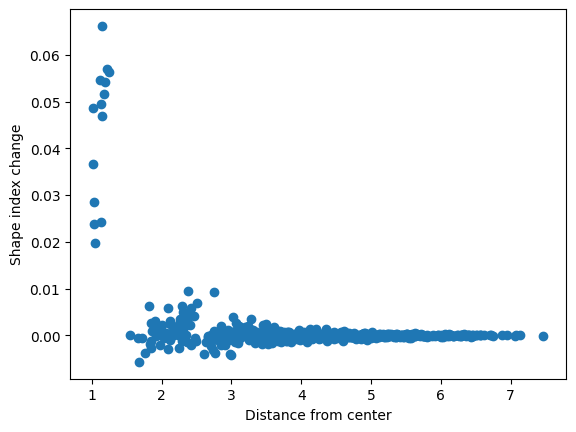

In [9]:
import numpy as np
r = []
s_c = []
sample = samples[7]
center = sample.cells_[211].center_
print(center)
for cellID,cell in sample.cells_.items():
    if cell.crossBoundary_:
        continue
    if cell.center_ is None:
        continue
    if cellID == 211:
        continue
    r.append(np.linalg.norm(center-cell.center_))
    s_c.append(cell.shape_index_change_)
import matplotlib.pyplot as plt
plt.xlabel("Distance from center")
plt.ylabel("Shape index change")
plt.scatter(r,s_c)

[4.77516348 5.50303469 4.56591798]


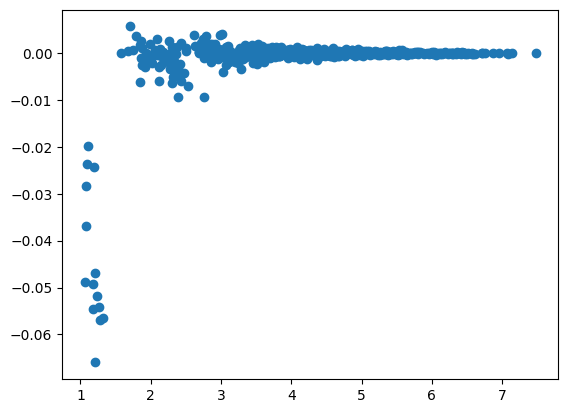

In [8]:
import numpy as np
r = []
s_c = []
sample = samples[8]
center = sample.cells_[211].center_
print(center)
for cellID,cell in sample.cells_.items():
    if cell.crossBoundary_:
        continue
    if cell.center_ is None:
        continue
    if cellID == 211:
        continue
    r.append(np.linalg.norm(center-cell.center_))
    s_c.append(cell.shape_index_change_)
import matplotlib.pyplot as plt
plt.scatter(r,s_c)

In [4]:
from toolbox.minimization import FIREminimization

minimizer = FIREminimization.from_config("test/","8.bulk.txt")
minimizer.minimize_config()

Initialization start ...
Number of vertices: 2049
Maximum vertex ID: 7724
Number of edges: 4098
Maximum edge ID: 22100
Number of polygons: 2392
Maximum polygon ID: 3566
Number of cells: 343
Maximum cell ID: 342
Number of polygons with two neighboring cells: 2392/2392
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
Average s0: 5.2
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 100
box: 7 7 7 periodic boundary condition: 1 1 1

Editing cell properties for the following cells:
cellID: 7 v0: 1 s0: 5.7 is_fixed: 0
cellID: 302 v0: 1 s0: 5.7 is_fixed: 0
cellID: 199 v0: 1 s0: 5.7 is_fixed: 0
cellID: 264 v0: 1 s0: 5.7 is_fixed: 0

Initial F_rms: 0.116167

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.002       343.000     0           0           0.111022    12.113448   12.224470   0.116167    
100.00      46.119      343.000     0           0           0.133935  

7 5.681732471591994 1.0051678430533604
302 5.616970931686939 1.0078623469396126
199 5.6673404644898895 1.0060088839236583
264 5.656982356352325 1.006871905151834
301 5.357254773663966 1.00110812332115


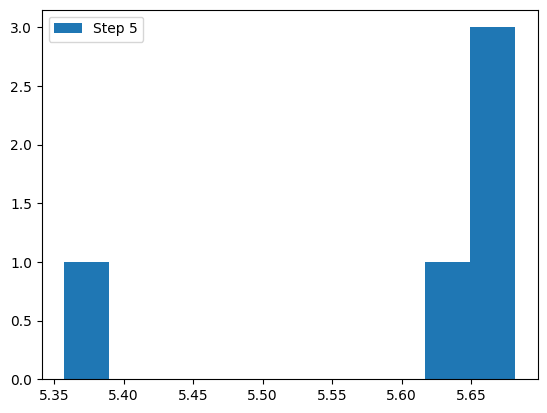

In [ ]:
from toolbox import training
import matplotlib.pyplot as plt
# for i in range(6):
#     tr = training.Training.from_config(config_dir= "7_0/", input_filename="{}.bulk.txt".format(i))
#     tr._config.load_periodic_tissue_cell_properties()
#     # for cellID,cell in tr._config.cells_.items():
#     #     print(cellID)
#     #     print(cell.shape_index_)
#     shape_indices = []
#     # for cellID,cell in tr._config.cells_.items():
#     for cellID in [7,302,199,264,301]:
#         cell = tr._config.cells_[cellID]
#         if cell.shape_index_ is not None:
#             print(cellID,cell.shape_index_, cell.volume_)
#             shape_indices.append(cell.shape_index_)
#     plt.hist(shape_indices, bins=10, label = "Step {}".format(i))
# plt.legend()
#     # tr.write_periodic_vtk(filename="{:07d}.sample.vtk".format(i))


tr = training.Training.from_config(config_dir= "test/", input_filename="minimized.txt")
# tr = training.Training.from_config(config_dir= "test/", input_filename="8.bulk.txt")

tr._config.load_periodic_tissue_cell_properties()
# for cellID,cell in tr._config.cells_.items():
#     print(cellID)
#     print(cell.shape_index_)
shape_indices = []
# for cellID,cell in tr._config.cells_.items():
for cellID in [7,302,199,264,301]:
    cell = tr._config.cells_[cellID]
    if cell.shape_index_ is not None:
        print(cellID,cell.shape_index_, cell.volume_)
        shape_indices.append(cell.shape_index_)
plt.hist(shape_indices, bins=10, label = "Step {}".format(i))
plt.legend()
    # tr.write_periodic_vtk(filename="{:07d}.sample.vtk".format(i))

In [ ]:
# Single fixed cell pulse drive
from toolbox import training
tr = training.Training.from_config(config_dir = "7_6/", input_filename = "minimized.txt")
tr.set_expansion_factor(0.25)
tr.pick_fixed_cell()
tr.pulse_drive(n_iterations = 10)


Initialization start ...
Number of vertices: 2044
Maximum vertex ID: 6125
Number of edges: 4088
Maximum edge ID: 16994
Number of polygons: 2387
Maximum polygon ID: 3306
Number of cells: 343
Maximum cell ID: 342
Number of polygons with two neighboring cells: 2387/2387
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
s0: 5.2
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 7 7 7 periodic boundary condition: 1 1 1
Initialization start ...
Fixing vertices for the following cells: 
40
Initial F_rms: 0.0260742

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.002       343.000     0           0           0.189543    12.399521   12.589064   0.026074    
100.00      40.380      343.000     6           5           0.132618    12.575743   12.708361   0.017137    
200.00      41.159      343.000     1           3           0.127595    12.488980   12.616575   0.016

In [1]:
from toolbox import training
tr = training.Training.from_config(config_dir = "10_0/", input_filename = "minimized.txt")
tr.set_stepsize(0.1)
# tr.set_expansion_factor(0.25)
tr.pick_fixed_pair()
# tr.pick_fixed_cell()
# tr.pulse_drive(n_iterations = 10)
tr.set_minimum_separation(4.5)
tr.pair_drive(n_oscillations = 5)
# # tr.load_fixed_cells()
# tr.pick_fixed_pair()
# tr.run()
# # tr.minimize_config()

Initialization start ...
Number of vertices: 5976
Maximum vertex ID: 22469
Number of edges: 11952
Maximum edge ID: 64253
Number of polygons: 6976
Maximum polygon ID: 10587
Number of cells: 1000
Maximum cell ID: 999
Number of polygons with two neighboring cells: 6976/6976
time: 0 ~ 3000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
s0: 5.2
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 10 10 10 periodic boundary condition: 1 1 1
Initialization start ...
Fixing vertices for the following cells: 
653
383
Initial F_rms: 0.198028

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.005       1000.000    0           0           2.390240    62.202662   64.592902   0.198028    
100.00      136.899     1000.000    78          78          0.352774    35.719212   36.071987   0.017163    
200.00      135.128     1000.000    20          22          0.350016    35.359518   35.709